## VIRGA Brown Dwawrfs Atmosphere Modeling - Example Notebook (PTYS 568)

In [1]:
# Set environment variables for PICASO reference data    
picaso_refdata = "/Users/nguyendat/Documents/GitHub/picaso/reference/"
pysyn_cdbs = "/Users/nguyendat/Documents/GitHub/picaso/reference/stellar_spectra/grp/redcat/trds"
picaso_home = '/Users/nguyendat/Documents/GitHub/picaso/'

import os 
"""Set environment variables for PICASO reference data."""
os.environ['picaso_refdata'] = picaso_refdata
os.environ['PYSYN_CDBS'] = pysyn_cdbs

from picaso import justdoit as jdi
from virga import justdoit as vjdi

import importlib
importlib.reload(vjdi)

#plot tools
from picaso import justplotit as jpi
from virga import justplotit as vjpi

import astropy.units as u
import pandas as pd
from bokeh.plotting import show, figure
from bokeh.io import output_notebook 
output_notebook()

import pickle as pickle
import numpy as np

Loading BokehJS ...

### Configure Picaso atmosphere case function

In [2]:
#point to where you untared your sonora profiles
sonora_profile_db = '/Users/nguyendat/Documents/GitHub/picaso/data/sonora_profile/'

def configure_atm(C_to_O=0.55, mh=1.0, Teff=1200,
                  gravity=10000, kzz=1e7, phase=0, wave_range=[1,6], 
                  eq = False, excluded_mol = None):
    """
    This function configures a brown dwarf atmosphere with the following inputs:
    C_to_O: float, carbon to oxygen ratio
    mh: float, metallicity in [M/H], default: 1.0, solar.  VIRGA BROWN DWARF WILL GIVE ERROR FOR MH.
    Teff: int, effective temperature in Kelvin
    gravity: float, surface gravity in m/s^2
    kzz: float, vertical mixing coefficient in cm^2/s
    phase: float, phase angle in radians
    wave_range: list, wavelength range in microns [min, max]
    eq: bool, whether to use chemical equilibrium (True) or disequilibrium (False)
    """
    
    opa = jdi.opannection(wave_range=wave_range) # define opacity range
    bd = jdi.inputs(calculation='browndwarf') # define brown dwarf model/ use no star
    bd.phase_angle(phase) #radians #phase angle of 0 is full phase
    bd.gravity(gravity=gravity, gravity_unit=u.Unit('m/(s**2)')) #any astropy units available

    #this function will grab the gravity you have input above and find the nearest neighbor with the 
    #note sonora chemistry grid is on the same opacity grid as our opacities (1060). 
    bd.sonora(sonora_profile_db, Teff) # get sonora profile closest to Teff and input gravity

    if eq: # if using chemical equilibrium
        bd.chemeq_visscher(C_to_O, mh) # compute chemeq with visscher grid

    # Add kzz (vertical mixing) to the profile
    profile = bd.inputs['atmosphere']['profile'] 
    profile['kzz'] = np.ones(profile['pressure'].shape[0])*[kzz]
    profile['kz'] = profile['kzz'].copy() # virga wants it named 'kz' so add it again

    bd.atmosphere(df=profile, exclude_mol=excluded_mol) # input the profile with disequilibrium chemistry

    print('====== Configured a brown dwarf atmosphere with: ======')
    print(f'Teff: {Teff} K, log(g): {np.log10(gravity)}, C/O: {C_to_O}, [M/H]: {mh}, kzz: {kzz} cm^2/s')

    return bd, opa, profile

# let's try to make a normal atmosphere
bd, opa, profile = configure_atm(C_to_O=0.55)

fig=figure(y_axis_type="log",x_axis_type='log', y_range=(1e3, 1e-6))

# Example: plot the Sonora profile gases for CO and CO2 with pressure on y-axis
p = profile['pressure']

print('Profile Gases Molecules:', bd.inputs['atmosphere']['profile'].keys())

fig.line(profile['CO'], p, legend_label='CO', line_width=2, color='red')
fig.line(profile['H2O'], p, legend_label='H2O', line_width=2, color='blue')
fig.line(profile['CH4'], p, legend_label='CH4', line_width=2, color='green')
fig.line(profile['CO2'], p, legend_label='CO2', line_width=2, color='orange')
fig.xaxis.axis_label = "Concentration"
fig.yaxis.axis_label = "Pressure (bar)"
show(fig)


====== Configured a brown dwarf atmosphere with: ======
Teff: 1200 K, log(g): 4.0, C/O: 0.55, [M/H]: 1.0, kzz: 10000000.0 cm^2/s
Profile Gases Molecules: Index(['pressure', 'temperature', 'e-', 'H2', 'H', 'H+', 'H-', 'H2-', 'H2+',
       'H3+', 'He', 'H2O', 'CH4', 'CO', 'NH3', 'N2', 'PH3', 'H2S', 'TiO', 'VO',
       'Fe', 'FeH', 'CrH', 'Na', 'K', 'Rb', 'Cs', 'CO2', 'HCN', 'C2H2', 'C2H4',
       'C2H6', 'SiO', 'MgH', 'OCS', 'Li', 'LiOH', 'LiH', 'LiCl', 'graphite',
       'Al', 'CaH', 'kzz', 'kz'],
      dtype='object')


In [3]:
profile.keys()

Index(['pressure', 'temperature', 'e-', 'H2', 'H', 'H+', 'H-', 'H2-', 'H2+',
       'H3+', 'He', 'H2O', 'CH4', 'CO', 'NH3', 'N2', 'PH3', 'H2S', 'TiO', 'VO',
       'Fe', 'FeH', 'CrH', 'Na', 'K', 'Rb', 'Cs', 'CO2', 'HCN', 'C2H2', 'C2H4',
       'C2H6', 'SiO', 'MgH', 'OCS', 'Li', 'LiOH', 'LiH', 'LiCl', 'graphite',
       'Al', 'CaH', 'kzz', 'kz'],
      dtype='object')

### Explore condensation curves of various molecules

In [4]:
#get pyeddy recommendation for which gases to run
metallicity = 1
mean_molecular_weight = 2.2
recommended_gases = vjdi.recommend_gas(profile['pressure'], profile['temperature'],
                                     mh=metallicity, mmw=mean_molecular_weight, 
                                     plot=True, plot_width=800, plot_height=600)

recommended_gases = [item for item in recommended_gases if item != 'CaAl12O19'] # remove CaAl12O19 as mieff is not in the virga database

# Make sure to check available condensates in virga

# Only these gases have virga Mieff files
available_condensates = ['ZnS', 'TiO2', 'NH3', 'Na2S', 'MnS', 'MgSiO3', 'Mg2SiO4', 'KCl', 'H2O', 'Fe', 'Cr', 'CH4', 'CaTiO3', 'Al2O3']
print(available_condensates)

# Only keep recommended gases that are also available in virga
available_condensates = [item for item in recommended_gases if item in available_condensates]
print(available_condensates)


['ZnS', 'TiO2', 'NH3', 'Na2S', 'MnS', 'MgSiO3', 'Mg2SiO4', 'KCl', 'H2O', 'Fe', 'Cr', 'CH4', 'CaTiO3', 'Al2O3']
['Al2O3', 'CaTiO3', 'Cr', 'Fe', 'KCl', 'Mg2SiO4', 'MgSiO3', 'MnS', 'Na2S', 'TiO2', 'ZnS']


### Adding clouds

In [5]:
# EXAMPLE 1: CLEAR ATMOSPHERE
#let's get the cloud free spectrum for reference
clf = bd.spectrum(opa, full_output=True)

def convert_unit(df):
    x,y = df['wavenumber'], df['thermal'] #units of erg/cm2/s/cm
    xmicron = 1e4/x
    flamy = y*1e-8 #per anstrom instead of per cm
    sp = jdi.psyn.ArraySpectrum(xmicron, flamy, 
                                waveunits='um', 
                                fluxunits='FLAM')   
    sp.convert("um")
    sp.convert('Fnu') #erg/cm2/s/Hz

    x = sp.wave #micron
    y= sp.flux #erg/cm2/s/Hz
    df['fluxnu'] = y 
    x,y = jdi.mean_regrid(1e4/x, y, R=500) #wavenumber, erg/cm2/s/Hz
    df['regridy'] =  y
    df['regridx'] = x

    return df

clf = convert_unit(clf)
xclf, yclf = jdi.mean_regrid(clf['wavenumber'], clf['thermal'], R=300)

### Let's compare cloudfree spectra of two different models

# make a no-h20 atmosphere
# bd_noh2o, opa_noh2o, profile_noh2o = configure_atm(C_to_O=0.55, excluded_mol=['H2O'])
# clf_noh2o = bd_noh2o.spectrum(opa_noh2o, full_output=True)
# clf_noh2o = convert_unit(clf_noh2o)
# xclf2, yclf2 = jdi.mean_regrid(clf_noh2o['wavenumber'], clf_noh2o['thermal'], R=300)

# show(jpi.spectrum([xclf, xclf2],
#                      [yclf, yclf2], plot_width=800, plot_height=400,
#                      y_axis_label='Flux (erg/s/cm^2/Hz)',
#                      x_axis_label='Wavelength (micron)',
#                   legend=['Cloud Free','Cloud Free No H2O']))

In [6]:
### Plot condensation temperature of some species on top of the P-T profile
from bokeh.palettes import Category10_10  # or Category10_6 for 6 colors

fig = figure(y_axis_type="log",x_axis_type='log', y_range=(1e2, 1e-3), 
             width=800, height=600,
             x_axis_label='Temperature (K)',
             y_axis_label='Pressure (bar)')

gases = ['Cr', 'Fe', 'Al2O3', 'MgSiO3', 'Mg2SiO4', 'KCl', 'MnS', 'Na2S']
colors = Category10_10[:len(gases)] # get tableau colors up to number of gases

# plot the P-T profile
fig.line(profile['temperature'], profile['pressure'], 
         legend_label='P-T Profile', line_width=2, color='black',
         line_dash='dashed')

for i, gasName in enumerate(gases):
    #grab p,t from eddysed
    pgas, tgas = vjdi.condensation_t(gas_name=gasName, mh=1, mmw=2.2)
    fig.line(tgas, pgas, legend_label=gasName, line_width=2, 
             color=colors[i])

# Make legend interactive
fig.legend.click_policy = "mute"  # or "hide" to hide out instead

show(fig)
    

In [7]:
def configure_cloud(df, opacity, mmw=2.2, gases=['Mg2SiO4','TiO2','Al2O3','Fe','H2O'],
                    fsed=1, directory='/Users/nguyendat/Documents/GitHub/picaso/data/virga/', R=300):
    """
    This function configures clouds in a brown dwarf atmosphere with the following inputs:
    df: picaso atmosphere object
    opacity: picaso opacity object
    mmw: float, mean molecular weight
    gases: list, list of cloud species to include
    fsed: float, sedimentation efficiency parameter
    directory: str, directory to save cloud files
    """
    if gases == 'recommended':
        gases = available_condensates

    print('Using cloud species:', gases)
    # call virga to compute cloud profile and optical depth
    cld_out = df.virga(gases, directory, fsed = fsed, mmw = mmw)
    # VIRGA BROWN DWARF WILL GIVE ERROR FOR MH metalicity

    out = df.spectrum(opacity, full_output=True)
    out = convert_unit(out)
    x_cldy, y_cldy = jdi.mean_regrid(out['wavenumber'], out['thermal'], R=R)

    return x_cldy, y_cldy, cld_out, out

# fsed_i = 1.2

# gas = ['Fe', 'MgSiO3']
# x_cldy, y_cldy, cld_out, out = configure_cloud(bd, opa, fsed=fsed_i,
#                                               gases=gas)

# removal = ['Fe']
# gases1 = [item for item in gas if item not in removal]
# x_cldy1, y_cldy1, cld_out1, out1 = configure_cloud(bd, opa, fsed=fsed_i,
#                                                   gases=gases1)

# removal = ['MgSiO3']
# gases2 = [item for item in gas if item not in removal]
# # x_cldy2, y_cldy2, cld_out2, out2 = configure_cloud(bd, opa, fsed=fsed_i,
#                                                   gases=gases2)

# removal = ['Cr']
# gases3 = [item for item in available_condensates if item not in removal]
# x_cldy3, y_cldy3, cld_out3, out3 = configure_cloud(bd, opa, fsed=fsed_i,
#                                                   gases=gases3)

# removal = ['MgSiO3']
# gases4 = [item for item in available_condensates if item not in removal]
# x_cldy4, y_cldy4, cld_out4, out4 = configure_cloud(bd, opa, fsed=fsed_i,
#                                                   gases=gases4)

# removal = ['MnS', 'Na2S', 'KCl']
# gases5 = [item for item in available_condensates if item not in removal]
# x_cldy5, y_cldy5, cld_out5, out5 = configure_cloud(bd, opa, fsed=fsed_i,
#                                                   gases=gases5)

# removal = ['Na2S']
# gases6 = [item for item in available_condensates if item not in removal]
# x_cldy6, y_cldy6, cld_out6, out6 = configure_cloud(bd, opa, fsed=fsed_i,
#                                               gases=gases6)

In [11]:
# Plot all spectra everything
show(jpi.spectrum([x_cldy, x_cldy1, x_cldy2],
                     [y_cldy, y_cldy1, y_cldy2], 
                     plot_width=1000, plot_height=500,
                     y_axis_label='Flux (erg/s/cm^2/Hz)',
                     x_axis_label='Wavelength (micron)',
                     y_axis_type='log',
                     title='Cloudy spectra with different cloud species removed',
                  legend=['Fe + MgSiO3',
                     'No Fe (70bar)', 
                     'No MgSiO3 (20bar)'])
                     )

In [ ]:
# # Plot all spectra everything
# show(jpi.spectrum([x_cldy, x_cldy1, x_cldy2, x_cldy3, x_cldy4, x_cldy5, x_cldy6],
#                      [y_cldy, y_cldy1, y_cldy2, y_cldy3, y_cldy4, y_cldy5, y_cldy6], 
#                      plot_width=1000, plot_height=500,
#                      y_axis_label='Flux (erg/s/cm^2/Hz)',
#                      x_axis_label='Wavelength (micron)',
#                      y_axis_type='log',
#                      title='Cloudy spectra with different cloud species removed',
#                   legend=['Everything included',
#                      'No Al2O3, Fe (70bar)', 
#                      'No Mg2SiO4 (20bar)',
#                      'No Cr (10bar)',  
#                      'No MgSiO3 (20bar)', 
#                      'No MnS, Na2S,\n KCl (5bar)',
#                      'No Na2S (2bar)'])
#                      )

In [44]:
### Same as above but narrow condensates species and then remove one at a time

fsed_i = 1.2
condensates = ['Al2O3','Fe','MgSiO3', 'Mg2SiO4','Na2S']
x_cldy, y_cldy, cld_out, out = configure_cloud(bd, opa, fsed=fsed_i,
                                              gases=condensates)

removal = ['Fe']
gases = [item for item in condensates if item not in removal]
x_cldy1, y_cldy1, cld_out1, out1 = configure_cloud(bd, opa, fsed=fsed_i,
                                                  gases=gases)

removal = ['Al2O3']
gases = [item for item in condensates if item not in removal]
x_cldy2, y_cldy2, cld_out2, out2 = configure_cloud(bd, opa, fsed=fsed_i,
                                                  gases=gases)

removal = ['Mg2SiO4']
gases = [item for item in condensates if item not in removal]
x_cldy3, y_cldy3, cld_out3, out3 = configure_cloud(bd, opa, fsed=fsed_i,
                                                  gases=gases)

removal = ['MgSiO3']
gases = [item for item in condensates if item not in removal]
x_cldy4, y_cldy4, cld_out4, out4 = configure_cloud(bd, opa, fsed=fsed_i,
                                                  gases=gases)

removal = ['Na2S']
gases = [item for item in condensates if item not in removal]
x_cldy5, y_cldy5, cld_out5, out5 = configure_cloud(bd, opa, fsed=fsed_i,
                                                  gases=gases)

Using cloud species: ['Al2O3', 'Fe', 'MgSiO3', 'Mg2SiO4', 'Na2S']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:1.767431690933221e-07cm for the 0th gas at the 0th grid point; 9.027128029241593e-08cm for the 1th gas at the 0th grid point; 2.209104317828647e-07cm for the 2th gas at the 0th grid point; 2.1939401100649796e-07cm for the 3th gas at the 0th grid point; 2.0441025907648194e-07cm for the 0th gas at the 1th grid point; 1.044403163491814e-07cm for the 1th gas at the 1th grid point; 2.5544223403135485e-07cm for the 2th gas at the 1th grid point; 2.536903293275186e-07cm for the 3th gas at the 1th grid point; 2.3620804669150716e-07cm for the 0th gas at the 2th grid point; 1.2073001302218108e-07cm for the 1th gas at the 2th grid point; 2.9512086375258636e-07cm for the 2th gas at the 2th grid point; 2.9309864839675104e-07cm for the 3th gas at the 2th grid poi

In [47]:
show(jpi.spectrum([x_cldy, x_cldy1, x_cldy2, x_cldy3, x_cldy4, x_cldy5],
                     [y_cldy, y_cldy1, y_cldy2, y_cldy3, y_cldy4, y_cldy5], 
                     plot_width=1000, plot_height=500,
                     y_axis_label='Flux (erg/s/cm^2/Hz)',
                     x_axis_label='Wavelength (micron)',
                     y_axis_type='log',
                     title='Cloudy spectra with different cloud species removed',
                  legend=['Al2O3, Fe, MgSiO3,\n Mg2SiO4, Na2S',
                     'No Fe (70bar)', 
                     'No Al2O3 (70bar)',
                     'No Mg2SiO4 (20bar)',
                     'No MgSiO3 (20bar)', 
                     'No Na2S (2bar)'])
                     )

In [13]:
"""TESTING DIFFERENT FSED VALUES FOR DIFFERENT SPECIES"""
### Simplest case: L/T transition: thin Fe clouds and normal MgSiO3 clouds

gases = ['Fe', 'MgSiO3', 'Na2S']
a0, b0, c0 = 15,  1,      5
a1, b1, c1 = 14,  1.2,    3
a2, b2, c2 = 13,  1.5,    1

fsed_dict0 = {'Fe': a0, 'MgSiO3': b0, 'Na2S': c0}
fsed_dict1 = {'Fe': a1, 'MgSiO3': b1, 'Na2S': c1}
fsed_dict2 = {'Fe': a2, 'MgSiO3': b2, 'Na2S': c2}

opa_custom = jdi.opannection(wave_range=[1.0, 15.0]) # define opacity range

# Dict with same values
x0, y0, cld_out0, df_out0 = configure_cloud(
    bd, opa_custom, fsed=fsed_dict0,
    gases=gases, R=500)

x1, y1, cld_out1, df_out1 = configure_cloud(
    bd, opa_custom, fsed=fsed_dict1,
    gases=gases, R=500)

x2, y2, cld_out2, df_out2 = configure_cloud(
    bd, opa_custom, fsed=fsed_dict2,
    gases=gases, R=500)

Using cloud species: ['Fe', 'MgSiO3', 'Na2S']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:1.7818376472825065e-07cm for the 1th gas at the 0th grid point; 2.0633555660913758e-07cm for the 1th gas at the 1th grid point; 2.3874315098881316e-07cm for the 1th gas at the 2th grid point; 2.7602213844294887e-07cm for the 1th gas at the 3th grid point;  Turn off warnings by setting verbose=False.
Using cloud species: ['Fe', 'MgSiO3', 'Na2S']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:2.209104317828647e-07cm for the 1th gas at the 0th grid point; 2.5544223403135485e-07cm for the 1th gas at the 1th grid point; 2.9512086375258636e-07cm for the 1th gas at the 2th grid point;  Turn off warnings by setting verbose=False.
Using cloud species: 

In [16]:
show(jpi.spectrum([x0, x1, x2], [y0, y1, y2], 
                plot_width=1000, plot_height=500,
                y_axis_label='Flux (erg/s/cm^2/Hz)',
                x_axis_label='Wavelength (micron)',
                y_axis_type='log',
                title='Fsed per-species Comparison: L/T Transition MgSiO3 and Na2S is anti-correlated with thin Fe Clouds ',
                legend=[f'fe={a0}, si={b0}, s={c0}', 
                        f'fe={a1}, si={b1}, s={c1}', 
                        f'fe={a2}, si={b2}, s={c2}']))

In [88]:
"""TESTING DIFFERENT FSED VALUES FOR DIFFERENT SPECIES"""
### Simplest case: L/T transition: thin Fe clouds and normal MgSiO3 clouds

gases = ['Fe', 'MgSiO3', 'Na2S']
a0, b0, c0 = 14,    3.1,   4.6
a1, b1, c1 = 14,   3.5,   3.8
a2, b2, c2 = 14,    3.8,   2.8

fsed_dict0 = {'Fe': a0, 'MgSiO3': b0, 'Na2S': c0}
fsed_dict1 = {'Fe': a1, 'MgSiO3': b1, 'Na2S': c1}
fsed_dict2 = {'Fe': a2, 'MgSiO3': b2, 'Na2S': c2}

opa_custom = jdi.opannection(wave_range=[1.0, 15.0]) # define opacity range

# Dict with same values
x0, y0, cld_out0, df_out0 = configure_cloud(
    bd, opa_custom, fsed=fsed_dict0,
    gases=gases, R=500)

x1, y1, cld_out1, df_out1 = configure_cloud(
    bd, opa_custom, fsed=fsed_dict1,
    gases=gases, R=500)

x2, y2, cld_out2, df_out2 = configure_cloud(
    bd, opa_custom, fsed=fsed_dict2,
    gases=gases, R=500)

Using cloud species: ['Fe', 'MgSiO3', 'Na2S']
Using cloud species: ['Fe', 'MgSiO3', 'Na2S']
Using cloud species: ['Fe', 'MgSiO3', 'Na2S']


In [89]:
show(jpi.spectrum([x0, x1, x2], [y0, y1, y2], 
                plot_width=1000, plot_height=500,
                y_axis_label='Flux (erg/s/cm^2/Hz)',
                x_axis_label='Wavelength (micron)',
                y_axis_type='linear',
                title='Fsed per-species Comparison: L/T Transition MgSiO3 and Na2S is anti-correlated with thin Fe Clouds ',
                legend=[f'fe={a0}, si={b0}, s={c0}', 
                        f'fe={a1}, si={b1}, s={c1}', 
                        f'fe={a2}, si={b2}, s={c2}']))

In [ ]:
### Keep cloud config the same but vary C/O ratio to see effect on spectrum

gases = ['Fe', 'MgSiO3']
a, b = 14, 2.2
fsed_dict0 = {'Fe': a, 'MgSiO3': b-0.02}
fsed_dict1 = {'Fe': a, 'MgSiO3': b+0.04}
fsed_dict2 = {'Fe': a, 'MgSiO3': b+0.1}
colist = [-0.4, 0.0, 0.4]

bd_co1, opa_co1, profile_co1 = configure_atm(C_to_O=colist[0], eq=True) # has to set eq true to use chemeq C/O
x_co1, y_co1, cld_out_co1, df_out_co1 = configure_cloud(bd_co1, opa_co1, fsed=fsed_dict0, gases=gases, R=500)

bd_co2, opa_co2, profile_co2 = configure_atm(C_to_O=colist[1], eq=True)
x_co2, y_co2, cld_out_co2, df_out_co2 = configure_cloud(bd_co2, opa_co2, fsed=fsed_dict1, gases=gases, R=500)

bd_co3, opa_co3, profile_co3 = configure_atm(C_to_O=colist[2], eq=True)
x_co3, y_co3, cld_out_co3, df_out_co3 = configure_cloud( bd_co3, opa_co3, fsed=fsed_dict2, gases=gases, R=500)

====== Configured a brown dwarf atmosphere with: ======
Teff: 1200 K, log(g): 4.0, C/O: -0.3, [M/H]: 1.0, kzz: 10000000.0 cm^2/s
Using cloud species: ['Fe', 'MgSiO3']
====== Configured a brown dwarf atmosphere with: ======
Teff: 1200 K, log(g): 4.0, C/O: 0.0, [M/H]: 1.0, kzz: 10000000.0 cm^2/s
Using cloud species: ['Fe', 'MgSiO3']


In [13]:
show(jpi.spectrum([x_co1, x_co2, x_co3], [y_co1, y_co2, y_co3],
                plot_width=1000, plot_height=500,
                y_axis_label='Flux (erg/s/cm^2/Hz)',
                x_axis_label='Wavelength (micron)',
                y_axis_type='linear',
                title='C/O variation for cloudy spectrum',
                legend=[f'C/O = {colist[0]}, \n{fsed_dict0}', 
                        f'C/O = {colist[1]}, \n{fsed_dict1}', 
                        f'C/O = {colist[2]}, \n{fsed_dict2}']))

In [44]:
"""TESTING DIFFERENT FSED VALUES FOR DIFFERENT SPECIES"""

gases = ['Fe', 'MgSiO3', 'Mg2SiO4']
a0, b0, c0 = 12,    2.0,    1
a1, b1, c1 = 12,    1.75,    1.25
a2, b2, c2 = 12,    1.5,    1.5

fsed_dict0 = {'Fe': a0, 'MgSiO3': b0, 'Mg2SiO4': c0}
fsed_dict1 = {'Fe': a1, 'MgSiO3': b1, 'Mg2SiO4': c1}
fsed_dict2 = {'Fe': a2, 'MgSiO3': b2, 'Mg2SiO4': c2}

opa_custom = jdi.opannection(wave_range=[1.0, 15.0]) # define wave range

# Dict with same values
x0, y0, cld_out0, df_out0 = configure_cloud(
    bd, opa_custom, fsed=fsed_dict0, R=500,
    gases=gases)

x1, y1, cld_out1, df_out1 = configure_cloud(
    bd, opa_custom, fsed=fsed_dict1, R=500,
    gases=gases)

x2, y2, cld_out2, df_out2 = configure_cloud(
    bd, opa_custom, fsed=fsed_dict2, R=500,
    gases=gases)

Using cloud species: ['Fe', 'MgSiO3', 'Mg2SiO4']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:1.7696241363287198e-07cm for the 2th gas at the 0th grid point; 2.0492184533269938e-07cm for the 2th gas at the 1th grid point; 2.3710811655525808e-07cm for the 2th gas at the 2th grid point; 2.7413264443821275e-07cm for the 2th gas at the 3th grid point;  Turn off warnings by setting verbose=False.
Using cloud species: ['Fe', 'MgSiO3', 'Mg2SiO4']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:2.3021023652349138e-07cm for the 2th gas at the 0th grid point; 2.661111981441556e-07cm for the 2th gas at the 1th grid point; 3.073462444167023e-07cm for the 2th gas at the 2th grid point;  Turn off warnings by setting verbose=False.
Using cloud spec

In [45]:
show(jpi.spectrum([x0, x1, x2], [y0, y1, y2], 
                plot_width=1000, plot_height=500,
                y_axis_label='Flux (erg/s/cm^2/Hz)',
                x_axis_label='Wavelength (micron)',
                y_axis_type='log',
                title='Fsed per-species Comparison: Na2S is anti-correlated with the rest',
                legend=[f'Fsed: fe={a0}, sio3={b0}, sio4={c0}', 
                        f'Fsed: fe={a1}, sio3={b1}, sio4={c1}', 
                        f'Fsed: fe={a2}, sio3={b2}, sio4={c2}']))

In [93]:
"""TESTING DIFFERENT FSED VALUES FOR DIFFERENT SPECIES"""

## Only varying MgSiO3 and Mg2SiO4 fsed values
gases = ['Fe', 'Al2O3', 'MgSiO3', 'Mg2SiO4', 'Na2S']

a, b = 1.4, 2.4
a0, b0 = 1.6, 2.2
a1, b1 = 1.8, 2.0
a2, b2 = 2.0, 1.8
a3, b3 = 2.2, 1.6
a4, b4 = 2.4, 1.4

fsed_dict = {'Fe': a, 'Al2O3': a, 'MgSiO3': b, 'Mg2SiO4': b, 'Na2S': a}
fsed_dict0 = {'Fe': a0, 'Al2O3': a0, 'MgSiO3': b0, 'Mg2SiO4': b0, 'Na2S': a0}
fsed_dict1 = {'Fe': a1, 'Al2O3': a1, 'MgSiO3': b1, 'Mg2SiO4': b1, 'Na2S': a0}
fsed_dict2 = {'Fe': a2, 'Al2O3': a2, 'MgSiO3': b2, 'Mg2SiO4': b2, 'Na2S': a0}
fsed_dict3 = {'Fe': a3, 'Al2O3': a3, 'MgSiO3': b3, 'Mg2SiO4': b3, 'Na2S': a0}
fsed_dict4 = {'Fe': a4, 'Al2O3': a4, 'MgSiO3': b4, 'Mg2SiO4': b4, 'Na2S': a0}

# Dict with same values
x0, y0, cld_out0, df_out0 = configure_cloud(
    bd, opa, fsed=fsed_dict0,
    gases=gases)

x1, y1, cld_out1, df_out1 = configure_cloud(
    bd, opa, fsed=fsed_dict1,
    gases=gases)

x2, y2, cld_out2, df_out2 = configure_cloud(
    bd, opa, fsed=fsed_dict2,
    gases=gases)

x3, y3, cld_out3, df_out3 = configure_cloud(
    bd, opa, fsed=fsed_dict3,
    gases=gases)

x4, y4, cld_out4, df_out4 = configure_cloud(
    bd, opa, fsed=fsed_dict4,
    gases=gases)
    

Using cloud species: ['Fe', 'Al2O3', 'MgSiO3', 'Mg2SiO4', 'Na2S']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:1.2756195209746684e-07cm for the 0th gas at the 0th grid point; 2.4797118237391736e-07cm for the 1th gas at the 0th grid point; 1.4730782446018822e-07cm for the 0th gas at the 1th grid point; 2.8617823521697987e-07cm for the 1th gas at the 1th grid point; 1.6995029611518666e-07cm for the 0th gas at the 2th grid point; 1.9589077466350583e-07cm for the 0th gas at the 3th grid point; 2.2487235191853847e-07cm for the 0th gas at the 4th grid point; 2.5890811038216184e-07cm for the 0th gas at the 5th grid point; 2.9704348882629723e-07cm for the 0th gas at the 6th grid point;  Turn off warnings by setting verbose=False.
Using cloud species: ['Fe', 'Al2O3', 'MgSiO3', 'Mg2SiO4', 'Na2S']
Take caution in analyzing results. There have been a calculated particle

In [94]:
# show(jpi.spectrum([x0, x1, x2], [y0, y1, y2], 
#                 plot_width=1000, plot_height=500,
#                 y_axis_label='Flux (erg/s/cm^2/Hz)',
#                 x_axis_label='Wavelength (micron)',
#                 y_axis_type='log',
#                 title='Fsed per-species Comparison: Si is anti-correlated with the rest',
#                 legend=[f'fe,na={a0}, si={b0}', 
#                         f'fe,na={a1}, si={b1}', 
#                         f'fe,na={a2}, si={b2}']))

show(jpi.spectrum([x0, x1, x2, x3, x4], [y0, y1, y2, y3, y4],
                plot_width=1000, plot_height=500,
                y_axis_label='Flux (erg/s/cm^2/Hz)',
                x_axis_label='Wavelength (micron)',
                y_axis_type='log',
                title='Fsed per-species Comparison: Si is anti-correlated with the rest',
                legend=[f'fe,na={a0}, si={b0}', 
                        f'fe,na={a1}, si={b1}', 
                        f'fe,na={a2}, si={b2}',
                        f'fe,na={a3}, si={b3}',
                        f'fe,na={a4}, si={b4}']))

In [ ]:
out1 = jdi.get_contribution(bd, opa, at_tau=1)

# show(jpi.molecule_contribution(out1, opa, plot_width=700, plot_height=500,
#                                y_axis_label='Flux (erg/s/cm^2/cm)',
#                                x_axis_label='Wavenumber (1/cm)'))
# Plot molecule contribution

figs=[]
for i,it in zip([out1['tau_p_surface']],['bd']):
    wno=[]
    spec=[]
    labels=[]
    for j in i.keys():
        x,y = jdi.mean_regrid(opa.wno, i[j],R=100)
        if np.min(y)<4.5: # Bars
            wno+=[x]
            spec+=[y]
            labels +=[j]
    fig = jpi.spectrum(wno, spec, plot_width=700,plot_height=500,y_axis_label='Tau~1 Pressure (bars)',
                       y_axis_type='log',x_range=[1,5],
                         y_range=[2e2,1e-4],legend=labels)
    fig.title.text=it
    figs+=[fig]
jpi.show(jpi.row(figs))

In [88]:
### Changing fsed: 1: most cloudy, 7: least cloudy 
# fsed: sedimentation efficiency parameter, larger values correspond to thinner clouds with larger particles

tab = {'x':[], 'y':[], 'cld_out':[], 'out':[]}

gases = ['Fe', 'Al2O3', 'MgSiO3', 'Mg2SiO4', 'Na2S']
for fs in [1.8, 2.0, 2.2]:
    x_cldy, y_cldy, cld_out, out = configure_cloud(bd, opa, fsed=fs, gases=gases)
    [tab[key].append(val) for key, val in zip(['x', 'y', 'cld_out', 'out'], [x_cldy, y_cldy, cld_out, out])]
    print('done fsed = ', fs)


Using cloud species: ['Fe', 'Al2O3', 'MgSiO3', 'Mg2SiO4', 'Na2S']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:1.4696213775792874e-07cm for the 0th gas at the 0th grid point; 2.8484647173210616e-07cm for the 1th gas at the 0th grid point; 1.6958089079384564e-07cm for the 0th gas at the 1th grid point; 1.9549004514595287e-07cm for the 0th gas at the 2th grid point; 2.2514028244247766e-07cm for the 0th gas at the 3th grid point; 2.580525073402227e-07cm for the 0th gas at the 4th grid point; 2.968562914545786e-07cm for the 0th gas at the 5th grid point;  Turn off warnings by setting verbose=False.
done fsed =  1.8
Using cloud species: ['Fe', 'Al2O3', 'MgSiO3', 'Mg2SiO4', 'Na2S']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:1.66803679

In [92]:
show(jpi.spectrum(tab['x'], tab['y'],
                  plot_width=1000, plot_height=500,
                  legend=['fsed=1.8', 'fsed=2', 'fsed=2.2'], 
                  y_axis_type='log',
                  title='Cloudy Spectra with Different fsed'))

In [45]:
### Changing fsed: smaller is cloudier
# fsed: sedimentation efficiency parameter, larger values correspond to thinner clouds with larger particles
# test a low gravity case without CH4
tab = {'x':[], 'y':[], 'cld_out':[], 'out':[]}

# test using a lower gravity
bdlow, opalow, profilelow = configure_atm(C_to_O=0.55, Teff=1200, gravity=1000, kzz=1e7, excluded_mol=['CH4'])

for fs in [0.8, 1, 1.25, 1.5]:
    x_cldy, y_cldy, cld_out, out = configure_cloud(bdlow, opalow, fsed=fs, gases='recommended')
    # x_cldy, y_cldy, cld_out, out = configure_cloud(bd, opa, fsed=fs, gases='recommended')
    [tab[key].append(val) for key, val in zip(['x', 'y', 'cld_out', 'out'], [x_cldy, y_cldy, cld_out, out])]
    print('done fsed = ', fs)


====== Configured a brown dwarf atmosphere with: ======
Teff: 1200 K, log(g): 3.0, C/O: 0.55, [M/H]: 1.0, kzz: 10000000.0 cm^2/s
Using cloud species: ['ZnS', 'TiO2', 'NH3', 'Na2S', 'MnS', 'MgSiO3', 'Mg2SiO4', 'KCl', 'H2O', 'Fe', 'Cr', 'CH4', 'CaTiO3', 'Al2O3']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:9.906927685389285e-08cm for the 0th gas at the 0th grid point; 9.417453907144366e-08cm for the 1th gas at the 0th grid point; 2.1570485837779715e-07cm for the 3th gas at the 0th grid point; 1.0005987546194663e-07cm for the 4th gas at the 0th grid point; 1.2540030361055827e-07cm for the 5th gas at the 0th grid point; 1.245419937758193e-07cm for the 6th gas at the 0th grid point; 2.0116536991750662e-07cm for the 7th gas at the 0th grid point; 5.0811996941482425e-08cm for the 9th gas at the 0th grid point; 5.5963434665944154e-08cm for the 10th gas at the 0th gr

In [46]:
show(jpi.spectrum(tab['x'], tab['y'],
                  plot_width=1000, plot_height=500,
                  legend=['fsed=0.8', 'fsed=1', 'fsed=1.25', 'fsed=1.5'], 
                  title='Cloudy Spectra with Different fsed'))

In [59]:
### Changing fsed: smaller is cloudier
# fsed: sedimentation efficiency parameter, larger values correspond to thinner clouds with larger particles
# changing temperature to see where methane appears
tab = {'x':[], 'y':[], 'cld_out':[], 'out':[]}

# test using a lower gravity
bdl, opal, profilel = configure_atm(C_to_O=0.55, Teff=1200, gravity=250, kzz=1e7)

for fs in [0.8, 1, 1.25, 1.5]:
    x_cldy, y_cldy, cld_out, out = configure_cloud(bdl, opal, fsed=fs, gases='recommended')
    # x_cldy, y_cldy, cld_out, out = configure_cloud(bd, opa, fsed=fs, gases='recommended')
    [tab[key].append(val) for key, val in zip(['x', 'y', 'cld_out', 'out'], [x_cldy, y_cldy, cld_out, out])]
    print('done fsed = ', fs)


====== Configured a brown dwarf atmosphere with: ======
Teff: 1200 K, log(g): 2.3979400086720375, C/O: 0.55, [M/H]: 1.0, kzz: 10000000.0 cm^2/s
Using cloud species: ['Al2O3', 'CaTiO3', 'Cr', 'Fe', 'KCl', 'Mg2SiO4', 'MgSiO3', 'MnS', 'Na2S', 'TiO2', 'ZnS']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:8.610163281008552e-08cm for the 0th gas at the 0th grid point; 8.610163281008552e-08cm for the 1th gas at the 0th grid point; 4.801077533068625e-08cm for the 2th gas at the 0th grid point; 4.359082629247518e-08cm for the 3th gas at the 0th grid point; 1.7250317940098633e-07cm for the 4th gas at the 0th grid point; 1.068097776615223e-07cm for the 5th gas at the 0th grid point; 1.0754592873562499e-07cm for the 6th gas at the 0th grid point; 8.582180446025959e-08cm for the 7th gas at the 0th grid point; 1.8495756077204446e-07cm for the 8th gas at the 0th grid point; 

In [60]:
show(jpi.spectrum(tab['x'], tab['y'],
                  plot_width=1000, plot_height=500,
                  legend=['fsed=0.8', 'fsed=1', 'fsed=1.25', 'fsed=1.5'], 
                  title='Cloudy Spectra with Different fsed'))

In [19]:
print('Cloud Optical Depth at 1 mbar for fsed = 0.8, 1, 1.25, 1.5')
for cld_out in tab['cld_out']:
    show(vjpi.all_optics(cld_out))

Cloud Optical Depth at 1 mbar for fsed = 0.8, 1, 1.25, 1.5


In [21]:
tab['cld_out'][0].keys()

dict_keys(['pressure', 'pressure_unit', 'temperature', 'temperature_unit', 'wave', 'wave_unit', 'condensate_mmr', 'cond_plus_gas_mmr', 'mean_particle_r', 'droplet_eff_r', 'r_units', 'column_density', 'column_density_unit', 'opd_per_layer', 'single_scattering', 'asymmetry', 'opd_by_gas', 'condensibles', 'scalar_inputs', 'fsed', 'altitude', 'layer_thickness', 'z_unit', 'mixing_length', 'mixing_length_unit', 'kz', 'kz_unit', 'scale_height', 'cloud_deck'])

In [23]:
from bokeh.models import LinearColorMapper, LogTicker,BasicTicker, ColorBar,LogColorMapper,Legend
from bokeh.palettes import magma as colfun1
from bokeh.palettes import viridis as colfun2
from bokeh.layouts import gridplot

print('Cloud Optical Depth at 1 mbar for fsed = 4, 4.25, 4.5, 5')
# Create a list to store all the figures
figures = []

for cld_out in tab['cld_out']:
    dat01 = vjdi.picaso_format(cld_out['opd_per_layer'], cld_out['single_scattering'],
                               cld_out['asymmetry'])

    nwno = len(cld_out['wave'])
    nlayer = len(cld_out['pressure'])
    pressure = cld_out['pressure']

    pressure_label = 'Pressure (Bars)'
    wavelength_label = 'Wavelength (um)'
    wavelength = cld_out['wave']

    cols = colfun1(200)
    color_mapper = LinearColorMapper(palette=cols, low=0, high=1)

    # PLOT OPD
    scat01 = np.flip(np.reshape(dat01['opd'].values, (nlayer, nwno)), 0)

    xr, yr = scat01.shape
    cols = colfun2(200)[::-1]
    color_mapper = LogColorMapper(palette=cols, low=1e-3, high=10)

    f01 = figure(x_range=[0, yr], y_range=[0, xr],
                 x_axis_label=wavelength_label, y_axis_label=pressure_label,
                 title="Cloud Optical Depth Per Layer",
                 width=350, height=400)

    f01.image(image=[scat01], color_mapper=color_mapper, x=0, y=0, dh=xr, dw=yr)

    color_bar = ColorBar(color_mapper=color_mapper, ticker=LogTicker(),
                         label_standoff=12, border_line_color=None, location=(0, 0))
    f01.add_layout(color_bar, 'left')

    #CHANGE X AND Y AXIS TO BE PHYSICAL UNITS 
    #indexes for pressure plot 
    if (pressure is not None):
        pressure = ["{:.1E}".format(i) for i in pressure[::-1]] #flip since we are also flipping matrices
        npres = len(pressure)
        ipres = np.array(range(npres))
        #set how many we actually want to put on the figure 
        #hard code ten on each.. 
        ipres = ipres[::int(npres/10)]
        pressure = pressure[::int(npres/10)]
        #create dictionary for tick marks 
        ptick = {int(i):j for i,j in zip(ipres,pressure)}
        for i in [f01]:
            i.yaxis.ticker = ipres
            i.yaxis.major_label_overrides = ptick
    if (wavelength is not None):
        wave = ["{:.1F}".format(i) for i in wavelength]
        nwave = len(wave)
        iwave = np.array(range(nwave))
        iwave = iwave[::int(nwave/10)]
        wave = wave[::int(nwave/10)]
        wtick = {int(i):j for i,j in zip(iwave,wave)}
        for i in [f01]:
            i.xaxis.ticker = iwave
            i.xaxis.major_label_overrides = wtick 

    figures.append(f01)

# Arrange the figures in a grid layout with n columns
n = len(tab['cld_out'])  # Number of columns
grid = gridplot([figures[i:i + n] for i in range(0, len(figures), n)])

show(grid)


Cloud Optical Depth at 1 mbar for fsed = 4, 4.25, 4.5, 5


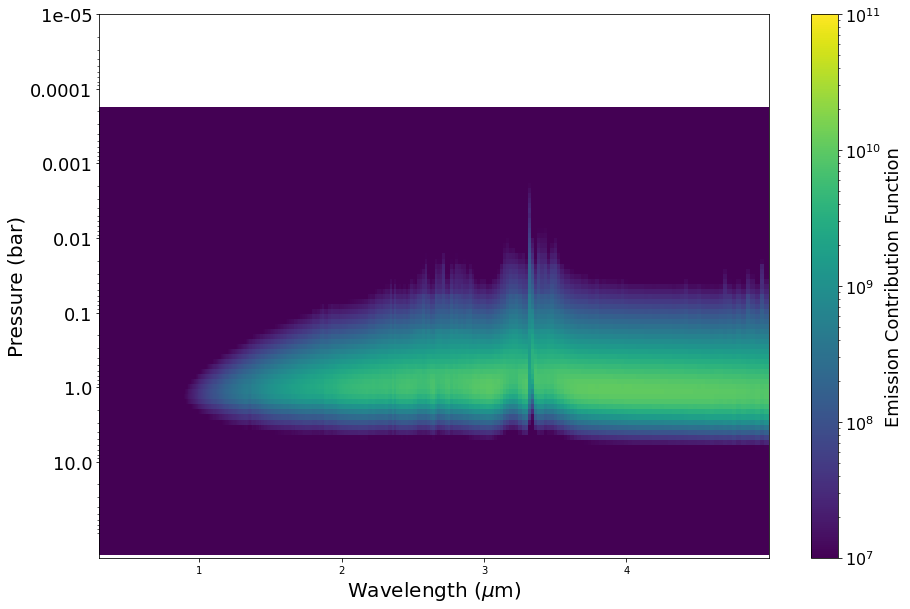

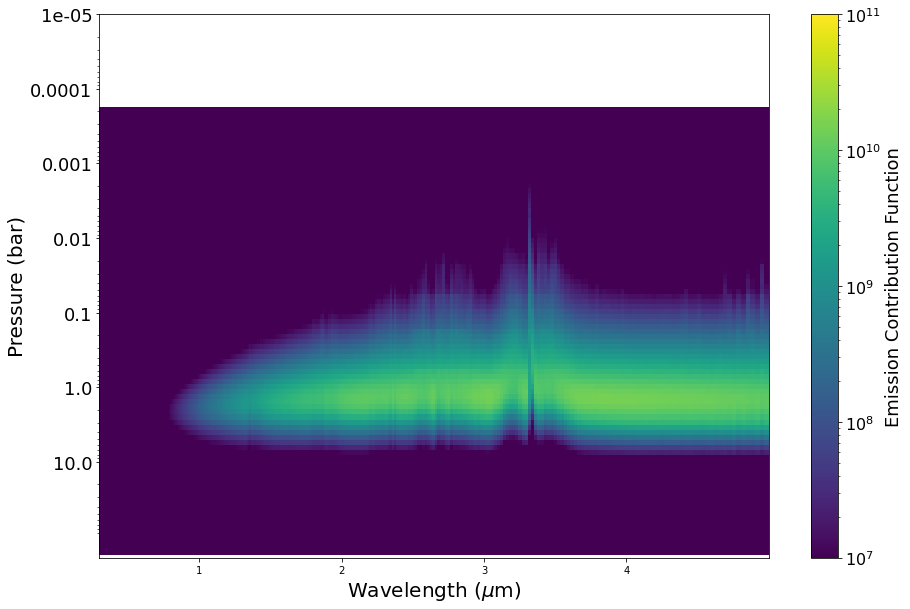

In [24]:
# thermal contribution function of different fsed: 0.8 and 1.
for i, out in enumerate(tab['out'][:2]):
    fig, ax, CF = jpi.thermal_contribution(out['full_output'], 
                                              norm=jpi.colors.LogNorm(vmin=1e7, vmax=1e11), R=150)


In [25]:
### Changing kzz
# kzz: vertical eddy diffusion coefficient, larger values correspond to stronger mixing and thicker clouds
# stronger vertical mixing, less efficient sedimentation, less cloudy

xarray, yarray, outarray = [], [], []
for kzzz in [1e5, 1e7, 1e9]:

    bd, opa, pf = configure_atm(C_to_O=0.55, mh=1.0, kzz=kzzz)
    
    # set fsed=1 for thick clouds
    x_cldy, y_cldy, cld_out, out = configure_cloud(bd, opa, fsed=1, gases='recommended')

    xarray.append(x_cldy), yarray.append(y_cldy), outarray.append(out)
    print('done kzz = ', kzzz)

show(jpi.spectrum(xarray, yarray,plot_width=1000, plot_height=500,
                  legend=['Kzz=1e5','Kzz=1e7', 'Kzz=1e9']))

====== Configured a brown dwarf atmosphere with: ======
Teff: 1200 K, log(g): 4.0, C/O: 0.55, [M/H]: 1.0, kzz: 100000.0 cm^2/s
Using cloud species: ['ZnS', 'TiO2', 'NH3', 'Na2S', 'MnS', 'MgSiO3', 'Mg2SiO4', 'KCl', 'H2O', 'Fe', 'Cr', 'CH4', 'CaTiO3', 'Al2O3']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:1.3853622102024562e-09cm for the 0th gas at the 0th grid point; 1.318393077996185e-09cm for the 1th gas at the 0th grid point; 3.011343859539457e-09cm for the 3th gas at the 0th grid point; 1.3992313400002195e-09cm for the 4th gas at the 0th grid point; 1.7538816413769923e-09cm for the 5th gas at the 0th grid point; 1.7418618364387279e-09cm for the 6th gas at the 0th grid point; 2.808345086681804e-09cm for the 7th gas at the 0th grid point; 7.126140486777216e-10cm for the 9th gas at the 0th grid point; 7.841059589761419e-10cm for the 10th gas at the 0th grid p

In [ ]:
### Changing kzz
# kzz: vertical eddy diffusion coefficient, larger values correspond to stronger mixing and thicker clouds
# stronger vertical mixing, less efficient sedimentation, less cloudy

# smaller kzz change
xarray, yarray, outarray = [], [], []
for kzzz in [5e6, 8e6, 1e7, 2e7]:

    bd, opa, pf = configure_atm(C_to_O=0.55, mh=1.0, kzz=kzzz)

    # set fsed the same
    x_cldy, y_cldy, cld_out, out = configure_cloud(bd, opa, fsed=1, gases='recommended')

    xarray.append(x_cldy), yarray.append(y_cldy), outarray.append(out)

    print('done kzz = ', kzzz)

====== Configured a brown dwarf atmosphere with: ======
Teff: 1200 K, log(g): 4.0, C/O: 0.55, [M/H]: 1.0, kzz: 5000000.0 cm^2/s
Using cloud species: ['Al2O3', 'CaTiO3', 'Cr', 'Fe', 'KCl', 'Mg2SiO4', 'MgSiO3', 'MnS', 'Na2S', 'TiO2', 'ZnS']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:7.110692546793531e-08cm for the 0th gas at the 0th grid point; 7.110692546793529e-08cm for the 1th gas at the 0th grid point; 3.974110658134284e-08cm for the 2th gas at the 0th grid point; 3.613525648705439e-08cm for the 3th gas at the 0th grid point; 1.4211943150081943e-07cm for the 4th gas at the 0th grid point; 8.824489603347916e-08cm for the 5th gas at the 0th grid point; 8.885424449239666e-08cm for the 6th gas at the 0th grid point; 7.087538743973015e-08cm for the 7th gas at the 0th grid point; 1.523945236146061e-07cm for the 8th gas at the 0th grid point; 6.682171055521692e

In [72]:
show(jpi.spectrum(xarray, yarray,plot_width=1000, plot_height=500,
                  legend=['Kzz=5e6','Kzz=8e6', 'Kzz=1e7', 'Kzz=2e7']))

In [71]:
### Changing metalicity, cloudy, fsed=1
# higher metallicity, higher temperature, less efficient cloud formation, less cloudy?

xarray2, yarray2, outarray = [], [], []
for c2o in [0.0, 0.55, 0.8, 0.95]:
    bd, opa, pf = configure_atm(C_to_O=c2o, eq=True) #chemical equilibrium for this test to use C/O ratio
    x_cldy, y_cldy, cld_out, out = configure_cloud(bd, opa, fsed=2, gases='recommended')
    xarray2.append(x_cldy), yarray2.append(y_cldy), outarray.append(out)
    print('done C/O = ', c2o)

show(jpi.spectrum(xarray2,
                     yarray2,plot_width=1000, plot_height=400,
                  legend=['C/O=0.0', 'C/O=0.55', 'C/O=0.8', 'C/O=0.95'],))

====== Configured a brown dwarf atmosphere with: ======
Teff: 1200 K, log(g): 4.0, C/O: 0.0, [M/H]: 1.0, kzz: 10000000.0 cm^2/s
Using cloud species: ['Al2O3', 'CaTiO3', 'Cr', 'Fe', 'KCl', 'Mg2SiO4', 'MgSiO3', 'MnS', 'Na2S', 'TiO2', 'ZnS']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:1.8228494329426613e-07cm for the 2th gas at the 0th grid point; 1.6680367913332253e-07cm for the 3th gas at the 0th grid point; 3.054967883207262e-07cm for the 9th gas at the 0th grid point; 2.1021579394509445e-07cm for the 2th gas at the 1th grid point; 1.9234417111646417e-07cm for the 3th gas at the 1th grid point; 2.4218129213535247e-07cm for the 2th gas at the 2th grid point; 2.2157213756447376e-07cm for the 3th gas at the 2th grid point; 2.7873080950577664e-07cm for the 2th gas at the 3th grid point; 2.549873070851938e-07cm for the 3th gas at the 3th grid point; 2.9185801928

In [38]:
fig, dndr = vjpi.radii(cld_out,at_pressure=1e-3)
show(fig)

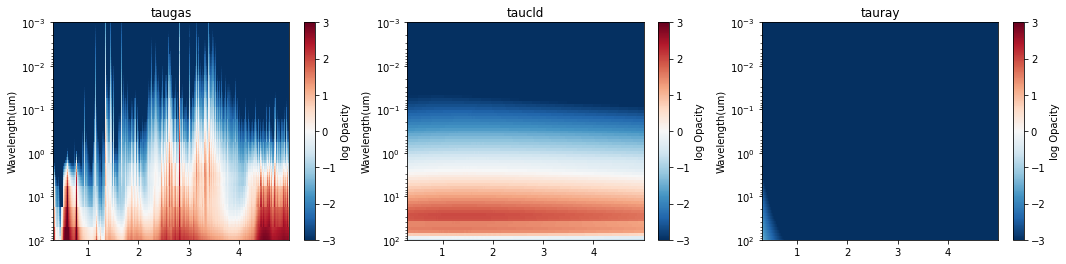

In [39]:
jpi.heatmap_taus(out)#['full_output'])

In [ ]:
### Changing fsed: smaller is cloudier
# fsed: sedimentation efficiency parameter, larger values correspond to thinner clouds with larger particles
# changing temperature to see where methane appears
tab = {'x':[], 'y':[], 'cld_out':[], 'out':[]}

# test using a log[g]=4 gravity

for fs in [1.0, 1.05, 1.1, 1.15]:
    x_cldy, y_cldy, cld_out, out = configure_cloud(bd, opa, fsed=fs, gases='recommended')
    [tab[key].append(val) for key, val in zip(['x', 'y', 'cld_out', 'out'], [x_cldy, y_cldy, cld_out, out])]
    print('done fsed = ', fs)


Using cloud species: ['Al2O3', 'CaTiO3', 'Cr', 'Fe', 'KCl', 'Mg2SiO4', 'MgSiO3', 'MnS', 'Na2S', 'TiO2', 'ZnS']
Take caution in analyzing results. There have been a calculated particle radii off the Mie grid, which has a min radius of 1e-08cm and distribution of 2. The following errors:1.426079664446073e-07cm for the 0th gas at the 0th grid point; 1.426079664446073e-07cm for the 1th gas at the 0th grid point; 7.973081435180878e-08cm for the 2th gas at the 0th grid point; 7.250668959330075e-08cm for the 3th gas at the 0th grid point; 2.848515562724555e-07cm for the 4th gas at the 0th grid point; 1.7696241363287198e-07cm for the 5th gas at the 0th grid point; 1.7818376472825065e-07cm for the 6th gas at the 0th grid point; 1.4214377844168723e-07cm for the 7th gas at the 0th grid point; 3.054297291241391e-07cm for the 8th gas at the 0th grid point; 1.3403421479051343e-07cm for the 9th gas at the 0th grid point; 1.40734253273315e-07cm for the 10th gas at the 0th grid point; 1.651543004600049

In [69]:
show(jpi.spectrum(tab['x'], tab['y'],
                  plot_width=1000, plot_height=500,
                  legend=['fsed=1.0', 'fsed=1.05', 'fsed=1.10', 'fsed=1.15'], 
                  title='Cloudy Spectra with Different fsed'))